# 02 — Time-series forecasters against the sequences

Before asking language models to *explain* a sequence, the paper asks a simpler
question: can dedicated time-series forecasters *continue* one?

Three were tested — **TimeGPT-1**, **Chronos** and **lag-llama** — against
CTM/BDM as the reference. CTM/BDM does not forecast; it identifies the rule that
generates the sequence, so it never misses. The gap between the two is the
result.

This notebook produces the **top and middle panels of Figure 1**, and all of
**Figure 2**.

**This is a closed experiment.** The forecasters were run once, in 2024, through
paid APIs and a local Chronos checkpoint. Their predictions are the committed
CSVs and are never re-forecast — re-running them would produce different numbers
and destroy the published result. Only the figures are regenerated here.

In [1]:
import pandas as pd
from IPython.display import Image

from superarc.timeseries import (
    BINARY_PANELS,
    PRINTED_PALETTE,
    RESTYLED_PALETTE,
    average_by_complexity,
    binary_success_rates,
    load_predictions,
    plot,
    plot_binary_panels,
)

pd.set_option("display.width", 140)

## Task 1 — guess the last digit of a binary sequence

Two pools. The first is the structured "simple climbers" from the paper's
sequence catalogue; the second is genuinely random binary strings, which nothing
can predict better than chance and which therefore acts as a floor.

`success` is 1 when the predicted final digit matched.

In [2]:
simple = binary_success_rates(BINARY_PANELS["figure01"][1])
random_pool = binary_success_rates(BINARY_PANELS["figure01-middle"][1])

pd.concat(
    {"simple climbers": simple, "random binary": random_pool}, axis=1
).round(2)

,simple climbers,random binary
,Success Rate (%),Success Rate (%)
CTM/BDM,100.00,100.0
timeGPT,41.67,57.0
chronos,45.83,53.0
lag-llama,70.83,58.0


Read the two columns together. On random sequences the forecasters sit near
50–58%, which is roughly what guessing a binary digit gets you. On the
*structured* sequences they do no better — TimeGPT-1 and Chronos actually do
**worse** (41.7% and 45.8%) than they did on noise.

That is the finding. Structure that a compressor exploits immediately is, to
these models, indistinguishable from noise. Only lag-llama shows a real gain
(70.8% vs 58.0%).

/Users/alberto/Documents/projects/medLLM/outputs/latest/figure01.png
/Users/alberto/Documents/projects/medLLM/outputs/latest/figure01-middle.png


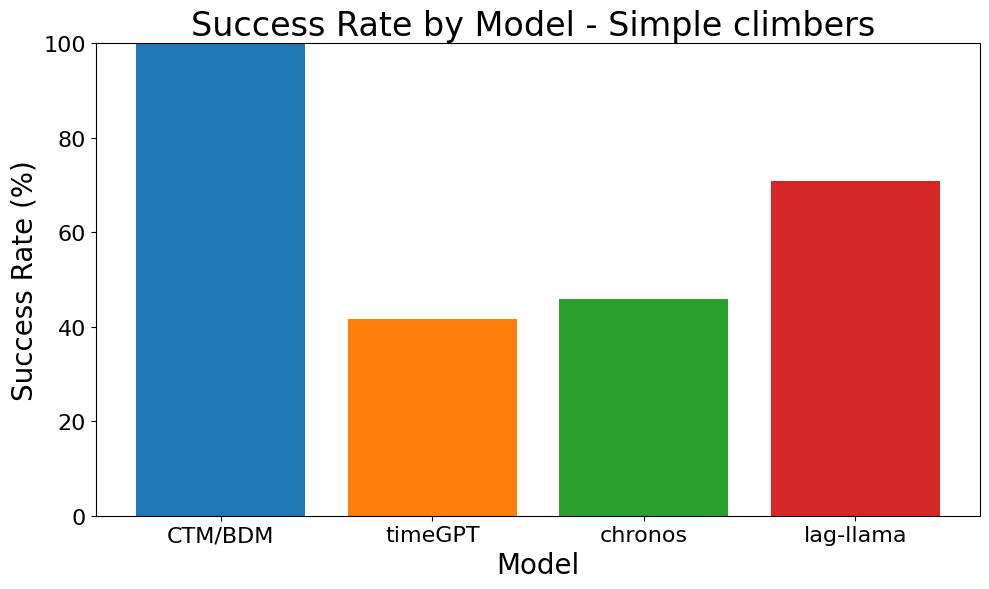

In [3]:
written = plot_binary_panels()
print(*[p for p in written if p.suffix == ".png"], sep="\n")

Image(filename=str(next(p for p in written if p.name == "figure01.png")))

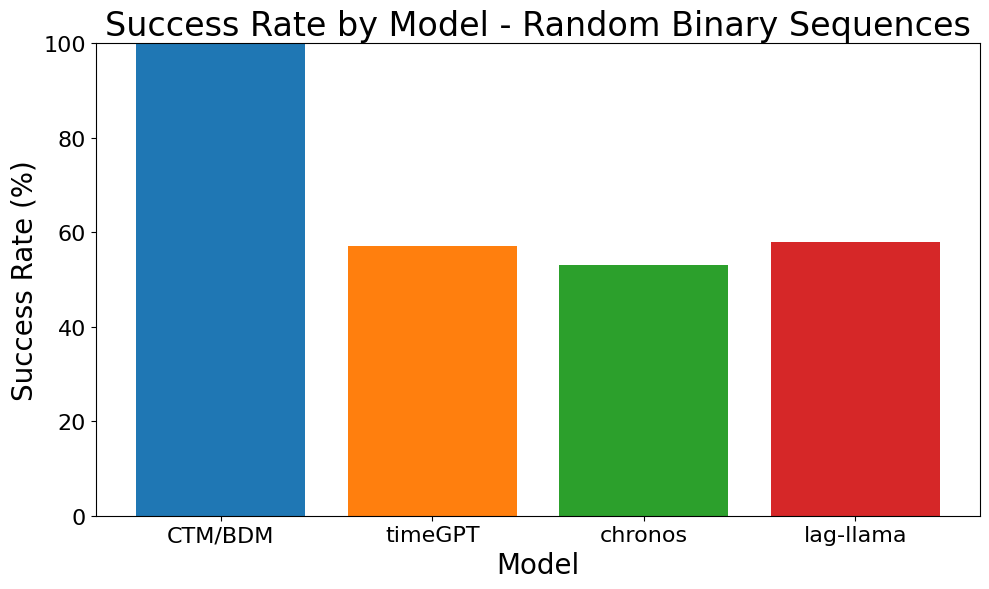

In [4]:
Image(filename=str(next(p for p in written if p.name == "figure01-middle.png")))

### A note on the colours

These two panels exist in two palettes and only one was printed.

`PRINTED_PALETTE` is matplotlib's default cycle and is what the article shows —
confirmed by sampling page 4 of the published PDF. `RESTYLED_PALETTE` is the
per-model scheme the other figures use, and is what sits in
`plots/highResolution/figure01.pdf`: a later restyle that never reached print.

Ruling (2026-09-12): **Figure 1 is the figure in the paper**, so the printed
palette is the default. The bar heights are identical either way, so no result
depends on the choice.

The restyle is kept for one reason. It is the only panel of Figure 1 that was
ever saved, so reproducing it pixel for pixel is the evidence that justified
trusting the two panels which have no file to compare against. That check now
lives in `tests/test_timeseries.py` rather than being discarded.

In [5]:
pd.DataFrame(
    {"printed in the article": PRINTED_PALETTE, "restyled, never printed": RESTYLED_PALETTE},
    index=["CTM/BDM", "timeGPT", "chronos", "lag-llama"],
)

,printed in the article,"restyled, never printed"
CTM/BDM,#1f77b4,#5cb8e6
timeGPT,#ff7f0e,#f77189
chronos,#2ca02c,#ef7d32
lag-llama,#d62728,#c69432


## Task 2 — continue a sequence, and measure how close you got

Each sequence is cut at 10%, 25% and 75% of its length, the forecaster predicts
the remainder, and three measures compare prediction against truth:

| measure | meaning |
|---|---|
| **sort similarity** | fraction of positions that match exactly |
| **general similarity** | overlap of the two value *sets*, ignoring order |
| **Levenshtein** | edit distance between the two as text |

The first two go up when the model does well; the third goes **down**.

In [6]:
predictions = load_predictions()

predictions.groupby(["forecasting_method_name", "seq_type"]).size().rename("rows")

forecasting_method_name  seq_type
chronos                  extended    120
                         original    120
lag-llama                original    120
timeGPT-1                extended    120
                         original    120
Name: rows, dtype: int64

### About the Levenshtein column

The original code took its edit distance from `enchant.utils`, a binding to a C
library that is not installed here, so `superarc.timeseries` reimplements it.
That replacement is not taken on trust — it reproduces **all 1920** published
distances in the four Chronos/TimeGPT files exactly.

Recovering them turned on a detail worth recording: the two call sites in the
original disagree about what they compare.

    compare_predictions     levenshtein("1 11 21", ...)        space-joined
    add_levenshtein_to_df   levenshtein("[1, 11, 21]", ...)    the printed list

Chronos and TimeGPT went through the first, lag-llama through the second, so the
published lag-llama distances are inflated by the brackets and commas. Both forms
are preserved exactly as published. Correcting that is an author's decision, not
a refactor.

In [7]:
averages = average_by_complexity(predictions)

averages.round(2)

,forecasting_method_name,seq_type,complexity,sort_simi_percen_10,sort_simi_percen_25,sort_simi_percen_75,gral_simi_percen_10,gral_simi_percen_25,gral_simi_percen_75,levenshtein_10,levenshtein_25,levenshtein_75
0,chronos,extended,1,15.00,8.00,3.33,25.56,26.79,19.29,2.93,6.67,26.33
1,chronos,extended,2,2.78,1.33,0.44,4.44,2.93,0.84,8.67,20.60,50.70
2,chronos,extended,3,0.00,2.00,0.00,5.56,6.84,0.12,3.63,9.23,40.53
4,chronos,original,1,20.00,11.67,7.14,20.00,20.56,18.17,1.17,3.00,9.60
5,chronos,original,2,3.33,3.33,1.43,3.33,2.22,2.37,3.93,5.47,15.33
6,chronos,original,3,3.33,0.00,0.00,3.33,1.11,0.26,2.07,4.70,18.47
8,lag-llama,original,1,3.33,0.00,2.38,3.33,0.00,7.09,2.00,3.77,10.37
9,lag-llama,original,2,3.33,0.00,0.95,3.33,1.11,1.14,4.00,5.87,15.97
10,lag-llama,original,3,0.00,0.00,0.48,0.00,0.00,0.26,2.67,5.40,18.23
12,timeGPT-1,extended,1,0.00,0.00,0.00,0.00,0.00,0.11,3.90,8.43,39.90


Complexity 3 and 4 are swapped before 4 is dropped — the same convention as
notebook 01. `lag-llama` has no `extended` rows because it was never run on that
pool.

/Users/alberto/Documents/projects/medLLM/outputs/latest/figure02-chronos-extended.png
/Users/alberto/Documents/projects/medLLM/outputs/latest/figure02-timeGPT-1-extended.png
/Users/alberto/Documents/projects/medLLM/outputs/latest/figure02-chronos-original.png
/Users/alberto/Documents/projects/medLLM/outputs/latest/figure02-lag-llama-original.png
/Users/alberto/Documents/projects/medLLM/outputs/latest/figure02-timeGPT-1-original.png


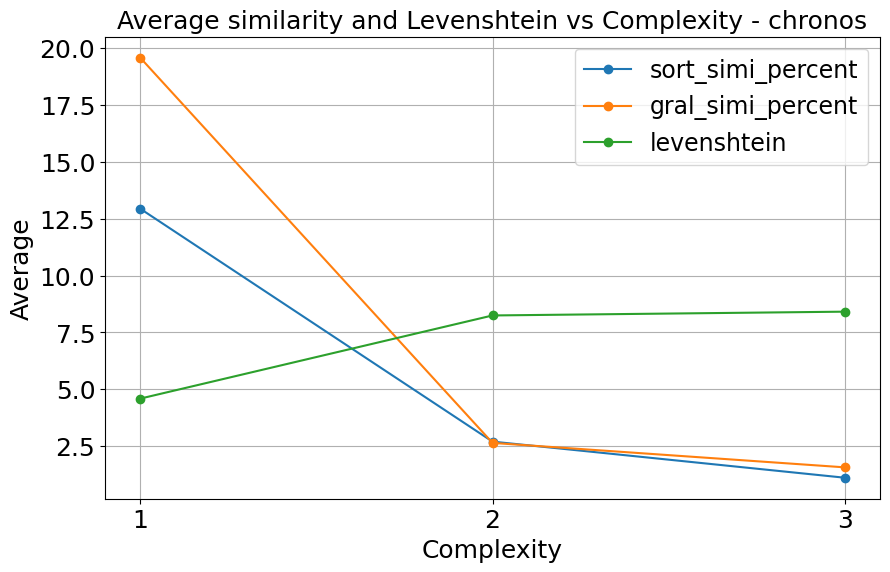

In [8]:
written = plot(averages)
print(*[p for p in written if p.suffix == ".png"], sep="\n")

Image(filename=str(next(p for p in written if p.name == "figure02-chronos-original.png")))

Similarity falls as complexity rises and edit distance climbs — the forecasts get
worse, and get worse faster than the sequences get harder.

### Figure 2 is not printed in the article

Its caption appears on page 5 of the published PDF, but the image above that
caption is the formulae figure. Only the caption was typeset.

So the panels are saved **one per file, exactly as the notebook draws them**. No
combined layout is invented here, because there is no published layout to match
and inventing one would quietly turn a production error into a new figure.

## Verification

Nothing above writes to `plots/` or `new_plots/`. Output goes to
`outputs/latest/` unless `SUPERARC_PLOTS_DIR` says otherwise.

In [9]:
from superarc.parity import check_figures

check_figures([
    "figure01.png",
    "figure01-middle.png",
    "figure02-chronos-original.png",
    "figure02-timeGPT-1-original.png",
    "figure02-lag-llama-original.png",
])

,figure,status,detail
0,figure01.png,changed,Fig 1 top simple climbers -- REPALETTED by au...
1,"Fig 1 middle binary success, random sequences",newly saved,never written to disk before; no reference exists
2,"Fig 2 similarity, chronos (caption only in pr...",newly saved,never written to disk before; no reference exists
3,"Fig 2 similarity, TimeGPT-1 (caption only in ...",newly saved,never written to disk before; no reference exists
4,"Fig 2 similarity, lag-llama (caption only in ...",newly saved,never written to disk before; no reference exists


In [10]:
import subprocess

dirty = subprocess.run(
    ["git", "status", "--porcelain", "new_plots/", "plots/"],
    capture_output=True, text=True,
).stdout.strip()

print(dirty if dirty else "clean: no published figure was modified")

clean: no published figure was modified
